In [3]:
!sudo apt install tesseract-ocr
!pip install pytesseract opencv-python-headless

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [4]:
from google.colab import files

print("Please upload your test image:")
uploaded = files.upload()

# Get the exact filename of the uploaded image
image_filename = list(uploaded.keys())[0]
print(f"Target image acquired: {image_filename}")

Please upload your test image:


Saving fifs.png to fifs.png
Target image acquired: fifs.png


Please upload your test image:


Saving fifs.png to fifs (1).png

Target image acquired: fifs (1).png

--- DEBUG STEP 1: THE BINARY MATRIX ---
If this image is unreadable, the AI cannot read it either.


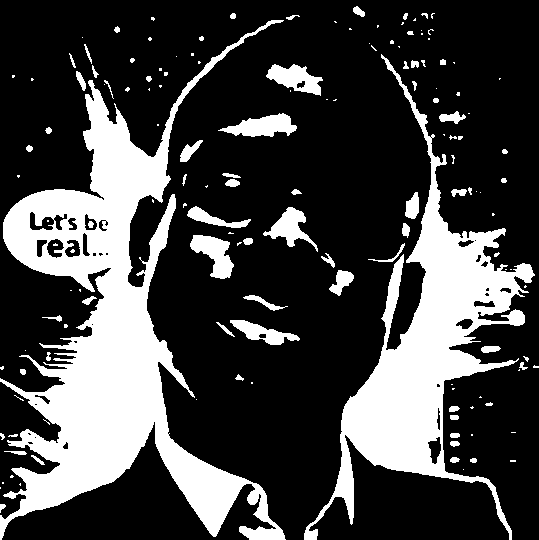


--- DEBUG STEP 2: RAW AI GUESSES (0% GATE) ---

--- FINAL VISUAL OUTPUT ---


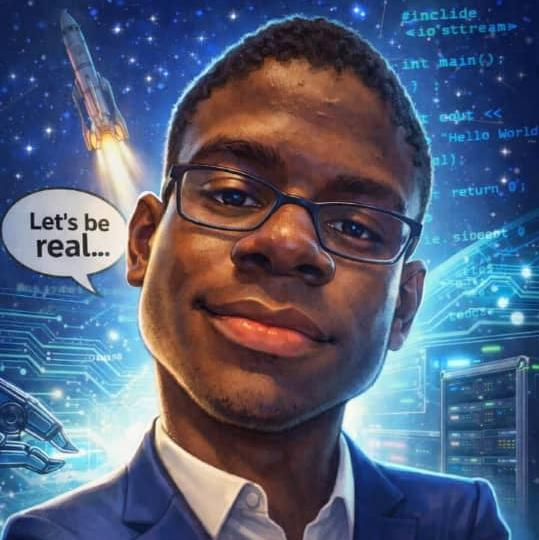

In [9]:
import cv2
import pytesseract
from pytesseract import Output
from google.colab.patches import cv2_imshow
from google.colab import files

# --- 1. ACQUIRE IMAGE ---
print("Please upload your test image:")
uploaded = files.upload()

if not uploaded:
    print("Upload cancelled or failed. Please run the cell again.")
else:
    # Get the exact filename of the file you just uploaded
    image_filename = list(uploaded.keys())[0]
    print(f"\nTarget image acquired: {image_filename}")

    # --- 2. PRE-PROCESS (THE LOGIC SKELETON) ---
    raw_img = cv2.imread(image_filename)

    # Convert to Grayscale
    gray_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur (Smooth noise)
    blurred_img = cv2.GaussianBlur(gray_img, (5, 5), 0)

    # Adaptive Thresholding (Force pure black and white)
    _, binary_img = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print("\n--- DEBUG STEP 1: THE BINARY MATRIX ---")
    print("If this image is unreadable, the AI cannot read it either.")
    cv2_imshow(binary_img)

    # --- 3. THE ENGINE & CONFIDENCE CHECK ---
    custom_config = r'--oem 3 --psm 3'
    d = pytesseract.image_to_data(binary_img, config=custom_config, output_type=Output.DICT)

    print("\n--- DEBUG STEP 2: RAW AI GUESSES (0% GATE) ---")
    n_boxes = len(d['text'])

    for i in range(n_boxes):
        # Ignore completely empty strings/background noise
        if int(d['conf'][i]) > -1:
            confidence = float(d['conf'][i])
            text = d['text'][i].strip()

            # THE DEBUG GATE: We dropped this from 80 to 0 to see EVERYTHING
            if confidence >= 0.0 and text:
                (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])

                # Draw the bounding box
                cv2.rectangle(raw_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

                # Overlay the text
                label = f"{text} ({confidence:.1f}%)"
                cv2.putText(raw_img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                print(f"Detected: '{text}' | Confidence: {confidence}%")

    print("\n--- FINAL VISUAL OUTPUT ---")
    cv2_imshow(raw_img)